In [17]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [18]:
from pathlib import Path

csv_path = Path.cwd() / "datasets" / "hormuz_trade_tier_continental_2026.csv"
if not csv_path.exists():
    csv_path = Path.cwd().parent / "datasets" / "hormuz_trade_tier_continental_2026.csv"

print(f"Loading dataset from: {csv_path}")
df = pd.read_csv(csv_path)
df.head()

Loading dataset from: c:\Users\sarat\hormuz_trade_analysis\datasets\hormuz_trade_tier_continental_2026.csv


,date,vessel_name,mmsi,flag,trade_tier,transit_status,toll_usd,rerouted,commodity,destination,...,insurance_cost_usd,days_delayed,extra_fuel_tonnes,reroute_penalty_usd,total_transit_cost_usd,naval_escort_status,estimated_cargo_value_usd,total_asset_value_at_risk_usd,continent,inflation_premium_per_unit
0,2026-03-01,MarchVessel_1,100000001,India,Privileged,Passed,0,No,Various,Global Port,...,40000,0,0,0,40000,Light (Cooperative),80000000,160000000,Asia,NaN
1,2026-03-01,MarchVessel_2,100000002,Iran,Privileged,Passed,0,No,Crude Oil,Hidden,...,70000,0,0,0,70000,Internal (IRGC Navy),240000000,380000000,Asia,0.035
2,2026-03-01,MarchVessel_3,100000003,Iran,Privileged,Passed,0,No,Crude Oil,Hidden,...,70000,0,0,0,70000,Internal (IRGC Navy),240000000,380000000,Asia,0.035
3,2026-03-02,MarchVessel_4,100000004,Greece,Taxed,Passed,2000000,No,Various,Global Port,...,1000000,0,0,0,3000000,NaN,80000000,160000000,Europe,NaN
4,2026-03-02,MarchVessel_5,100000005,Iran,Privileged,Passed,0,No,Crude Oil,Hidden,...,70000,0,0,0,70000,Internal (IRGC Navy),240000000,380000000,Asia,0.035


#preprocessing

In [19]:

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1890 entries, 0 to 1889
Data columns (total 23 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   date                           1890 non-null   str    
 1   vessel_name                    1890 non-null   str    
 2   mmsi                           1890 non-null   int64  
 3   flag                           1890 non-null   str    
 4   trade_tier                     1890 non-null   str    
 5   transit_status                 1890 non-null   str    
 6   toll_usd                       1890 non-null   int64  
 7   rerouted                       1890 non-null   str    
 8   commodity                      1890 non-null   str    
 9   destination                    1890 non-null   str    
 10  payment_rail                   1890 non-null   str    
 11  ship_hull_value_usd            1890 non-null   int64  
 12  insurance_premium_delta_pct    1890 non-null   float64
 13 

In [20]:
df.isnull().sum()

date                                0
vessel_name                         0
mmsi                                0
flag                                0
trade_tier                          0
transit_status                      0
toll_usd                            0
rerouted                            0
commodity                           0
destination                         0
payment_rail                        0
ship_hull_value_usd                 0
insurance_premium_delta_pct         0
insurance_cost_usd                  0
days_delayed                        0
extra_fuel_tonnes                   0
reroute_penalty_usd                 0
total_transit_cost_usd              0
naval_escort_status              1211
estimated_cargo_value_usd           0
total_asset_value_at_risk_usd       0
continent                           0
inflation_premium_per_unit        499
dtype: int64

In [21]:
#Handling naval_escort status
df['naval_escort_status'] = df['naval_escort_status'].fillna('Unknown')
#Handle inflation_premium_per_unit
df['inflation_premium_per_unit'] = df['inflation_premium_per_unit'].fillna(
    df['inflation_premium_per_unit'].mean()
)

In [22]:
df.isnull().sum()

date                             0
vessel_name                      0
mmsi                             0
flag                             0
trade_tier                       0
transit_status                   0
toll_usd                         0
rerouted                         0
commodity                        0
destination                      0
payment_rail                     0
ship_hull_value_usd              0
insurance_premium_delta_pct      0
insurance_cost_usd               0
days_delayed                     0
extra_fuel_tonnes                0
reroute_penalty_usd              0
total_transit_cost_usd           0
naval_escort_status              0
estimated_cargo_value_usd        0
total_asset_value_at_risk_usd    0
continent                        0
inflation_premium_per_unit       0
dtype: int64

In [23]:
df.drop_duplicates(inplace=True)

In [24]:
df['date'] = pd.to_datetime(df['date'])
df['year'] = df['date'].dt.year
df[['date', 'year']].head()

,date,year
0,2026-03-01,2026
1,2026-03-01,2026
2,2026-03-01,2026
3,2026-03-02,2026
4,2026-03-02,2026


In [26]:
save_path = csv_path.parent / "cleaned_hormuz_trade.csv"
save_path.parent.mkdir(parents=True, exist_ok=True)
df.to_csv(save_path, index=False)

#task4


In [ ]:
import os

os.makedirs("outputs/charts", exist_ok=True)

continent_trade = df.groupby('continent')['estimated_cargo_value_usd'].sum()

plt.figure(figsize=(12,6))

continent_trade.sort_values(ascending=False).plot(
    kind='bar'
)

plt.title("Continent-wise Trade Value Analysis")
plt.xlabel("Continent")
plt.ylabel("Cargo Value in USD")

plt.xticks(rotation=30)

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.savefig("outputs/charts/continent_trade_analysis.png")

plt.show()

NameError: name 'continent_trade' is not defined

<Figure size 1200x600 with 0 Axes>

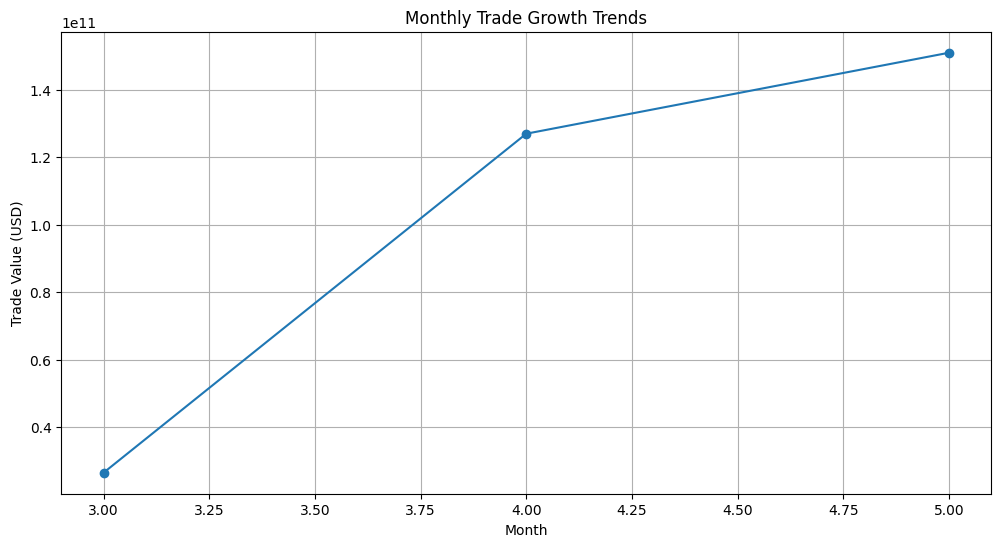

In [ ]:
df['month'] = df['date'].dt.month
df[['date', 'month']].head()
monthly_trade = df.groupby('month')['estimated_cargo_value_usd'].sum()

plt.figure(figsize=(12,6))

plt.plot(
    monthly_trade.index,
    monthly_trade.values,
    marker='o'
)

plt.title("Monthly Trade Growth Trends")
plt.xlabel("Month")
plt.ylabel("Trade Value (USD)")

plt.grid(True)
plt.savefig("outputs/charts/monthly_trade_trend.png")
plt.show()

In [ ]:
continent_month_trade = df.pivot_table(
    values='estimated_cargo_value_usd',
    index='month',
    columns='continent',
    aggfunc='sum'
)

continent_month_trade

NameError: name 'df' is not defined

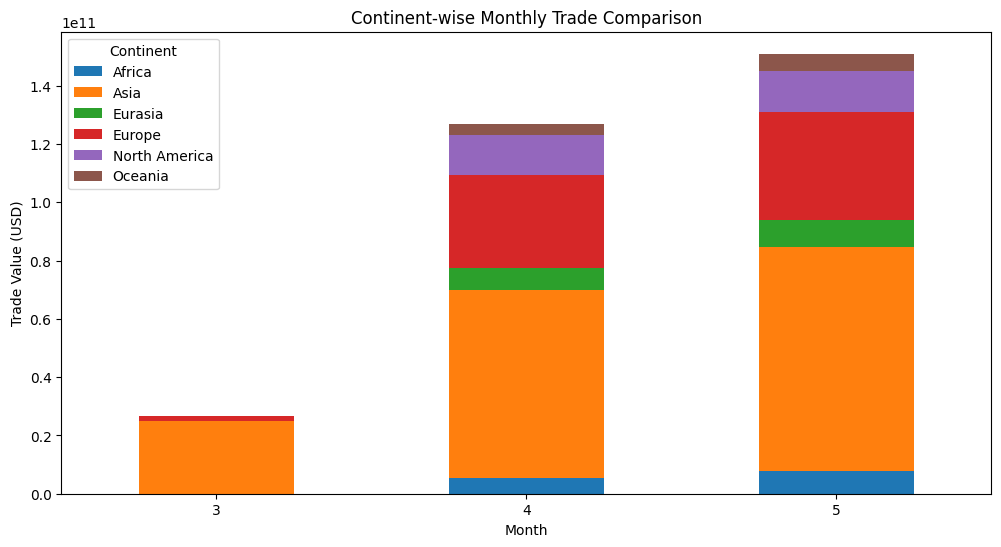

In [ ]:
continent_month_trade.plot(
    kind='bar',
    stacked=True,
    figsize=(12,6)
)

plt.title("Continent-wise Monthly Trade Comparison")
plt.xlabel("Month")
plt.ylabel("Trade Value (USD)")

plt.xticks(rotation=0)

plt.legend(title='Continent')
plt.savefig("outputs/charts/stacked_bar_trade.png")
plt.show()

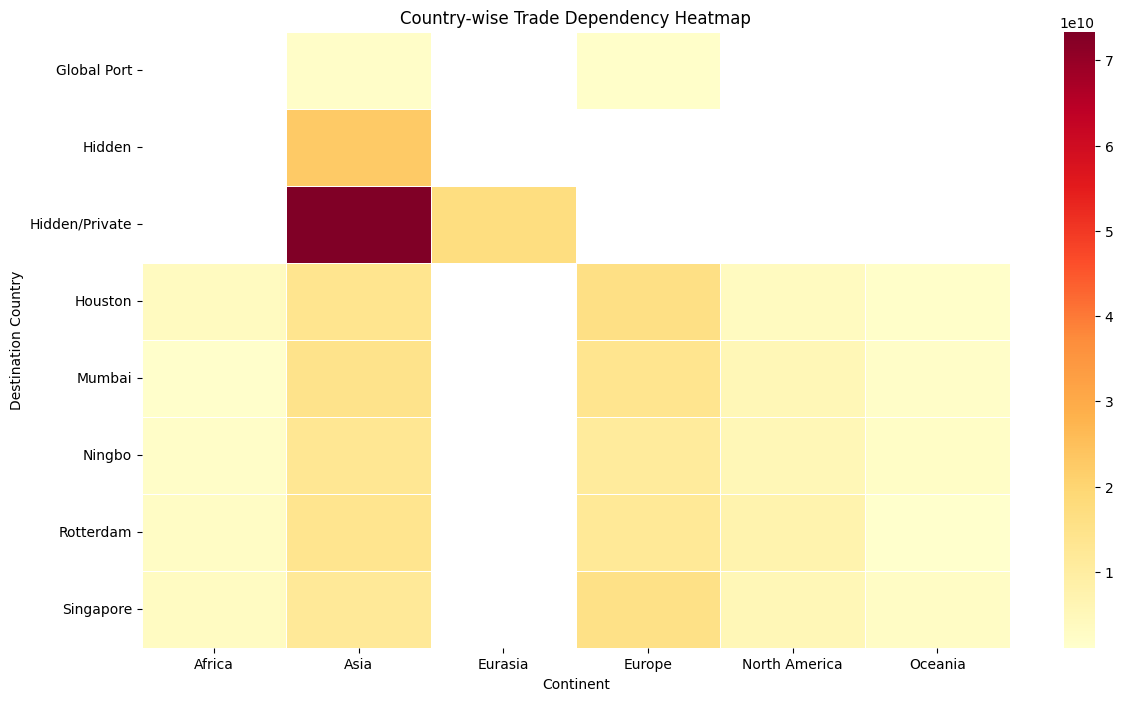

In [ ]:
country_dependency = df.pivot_table(
    values='estimated_cargo_value_usd',
    index='destination',
    columns='continent',
    aggfunc='sum'
)

plt.figure(figsize=(14,8))

sns.heatmap(
    country_dependency,
    cmap='YlOrRd',
    linewidths=0.5
)

plt.title("Country-wise Trade Dependency Heatmap")
plt.xlabel("Continent")
plt.ylabel("Destination Country")

plt.savefig("outputs/charts/country_dependency_heatmap.png")

plt.show()

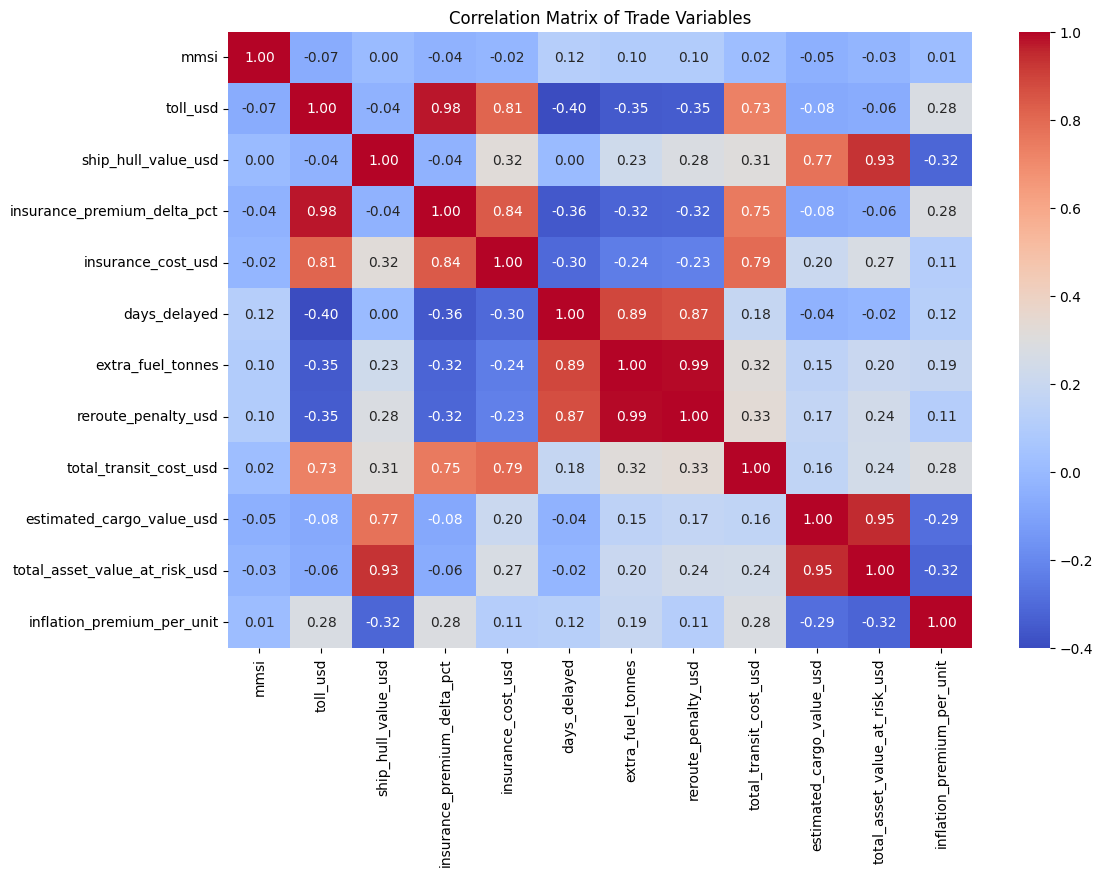

In [ ]:
numeric_data = df.select_dtypes(include=['float64', 'int64'])

correlation_matrix = numeric_data.corr()

plt.figure(figsize=(12,8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Matrix of Trade Variables")

plt.savefig("outputs/charts/correlation_matrix.png")

plt.show()

Strategic Recommendations

1. Countries should diversify trade routes to reduce overdependence on specific maritime corridors and improve economic stability.

2. Continents with rapidly increasing trade volumes should strengthen port infrastructure, logistics systems, and cargo management facilities.

3. Governments should invest in alternative transportation and energy trade routes to minimize geopolitical and supply chain risks.

4. Real-time trade monitoring and predictive analytics systems should be implemented to identify economic disruptions early.

5. International cooperation and maritime security measures should be enhanced to ensure safe and uninterrupted global trade operations.

6. Regions experiencing fluctuating trade trends should adopt trade stabilization policies and improve export-import balance strategies.

7. Insurance and risk management policies should be optimized to reduce financial losses caused by delays, rerouting, and geopolitical uncertainties.